In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
train = pd.read_csv('titanic_train.csv')

In [38]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

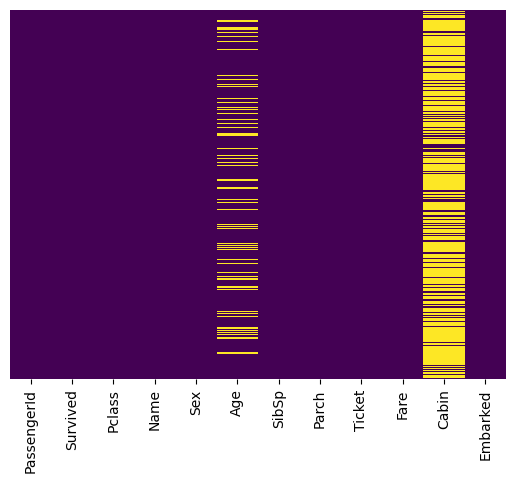

In [40]:
sns.heatmap(train.isnull(), yticklabels= False, cbar = False, cmap = 'viridis')

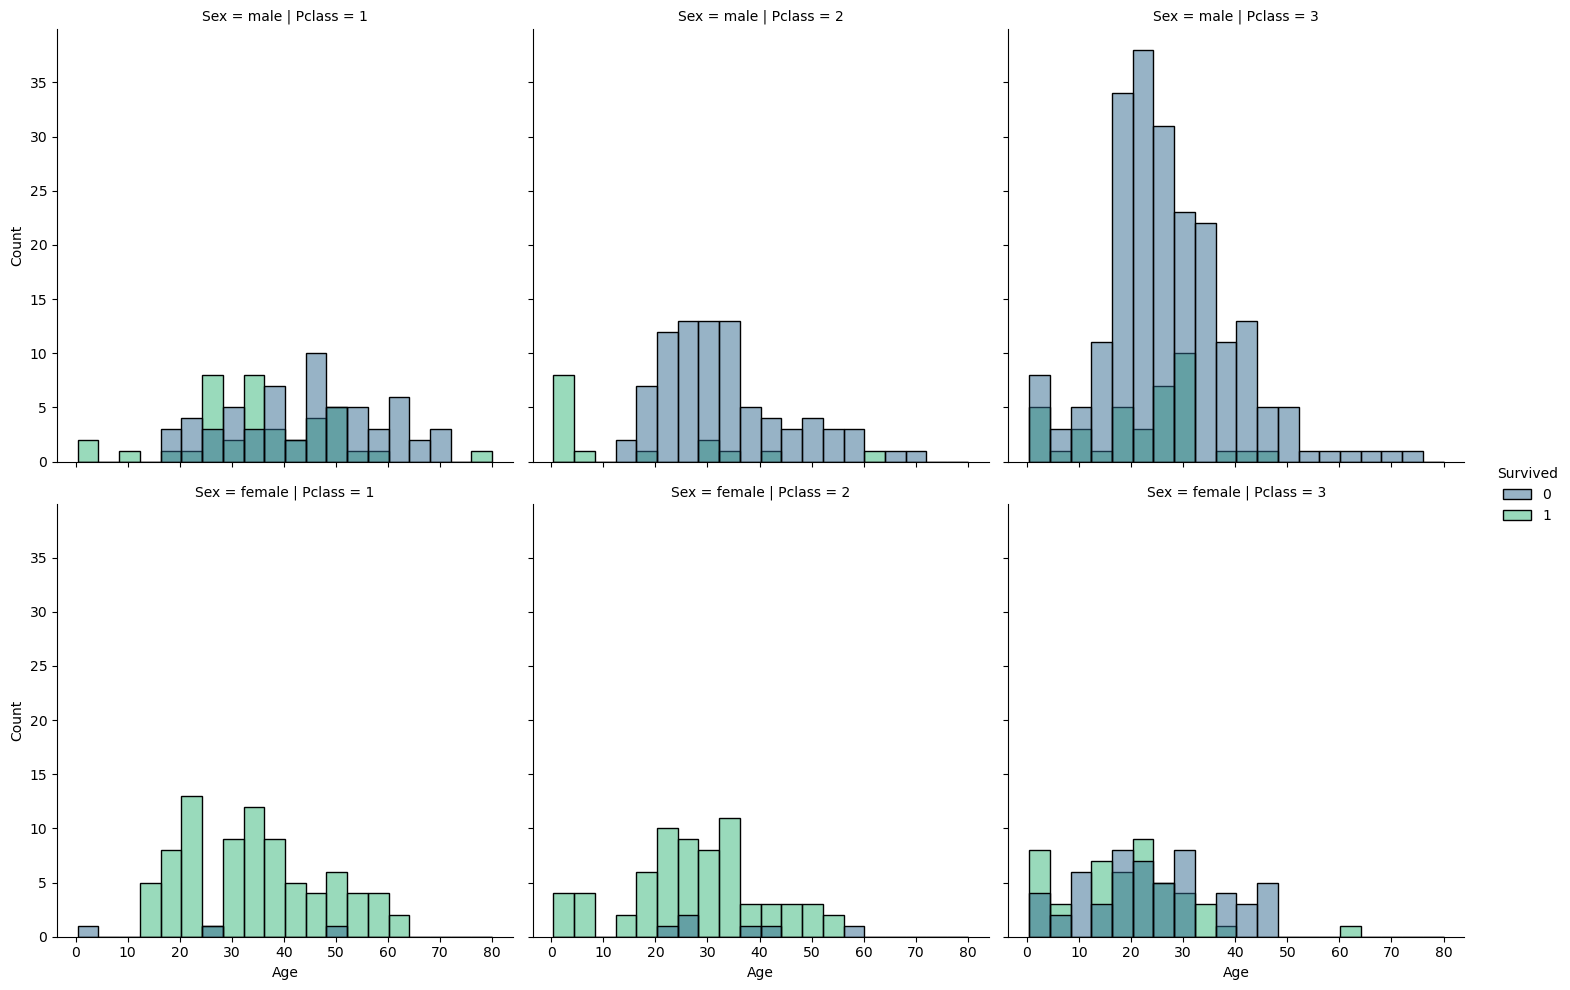

In [41]:
sns.displot(train, x = 'Age',row = 'Sex', col = 'Pclass', hue = 'Survived', palette='viridis')

In [42]:
def impute_age(row):
    if pd.isnull(row["Age"]):
        if row["Pclass"] == 1:
            return 37
        elif row["Pclass"] == 2:
            return 29
        else:
            return 24
    else:
        return row["Age"]

train["Age"] = train.apply(impute_age, axis=1)

<Axes: >

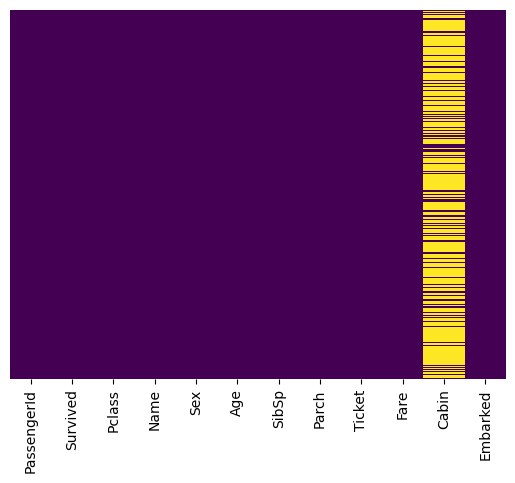

In [43]:
sns.heatmap(train.isnull(), yticklabels= False, cbar = False, cmap = 'viridis')

In [44]:
train.drop('Cabin', axis = 1, inplace= True)
train.dropna(inplace = True)

<Axes: >

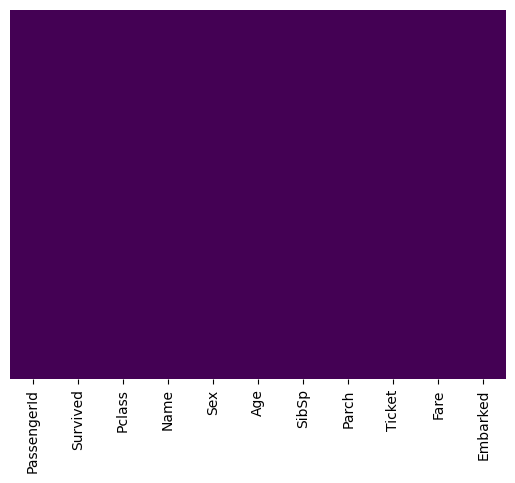

In [45]:
sns.heatmap(train.isnull(), yticklabels= False, cbar = False, cmap = 'viridis')

In [52]:
sex = pd.get_dummies(train['Sex'],dtype=float, drop_first=True)
sex.head()

,male
0,1.0
1,0.0
2,0.0
3,0.0
4,1.0


In [55]:
embark = pd.get_dummies(train['Embarked'], drop_first=True, dtype=float)
embark.head(10)

,Q,S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,1.0,0.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0
9,0.0,0.0


In [56]:
train = pd.concat([train,sex,embark], axis = 1)
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1.0,0.0,1.0


In [60]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1.0,0.0,1.0
1,2,1,1,38.0,1,0,71.2833,0.0,0.0,0.0
2,3,1,3,26.0,0,0,7.9250,0.0,0.0,1.0
3,4,1,1,35.0,1,0,53.1000,0.0,0.0,1.0
4,5,0,3,35.0,0,0,8.0500,1.0,0.0,1.0


In [61]:
train.drop(['PassengerId'], axis =1, inplace = True)
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,1.0,0.0,1.0


In [62]:
train2 = train

In [63]:
X = train.drop(['Survived'], axis = 1)
y = train['Survived']

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [95]:
from sklearn.linear_model import LogisticRegression

In [96]:
logmodel = LogisticRegression(max_iter=1000)

In [97]:
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [98]:
predictions = logmodel.predict(X_test)

In [99]:
from sklearn.metrics import classification_report

In [100]:
print (classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       163
           1       0.85      0.69      0.76       104

    accuracy                           0.83       267
   macro avg       0.84      0.81      0.82       267
weighted avg       0.83      0.83      0.83       267



In [101]:
from sklearn.metrics import confusion_matrix

In [102]:
confusion_matrix(y_test,predictions)

array([[150,  13],
       [ 32,  72]], dtype=int64)

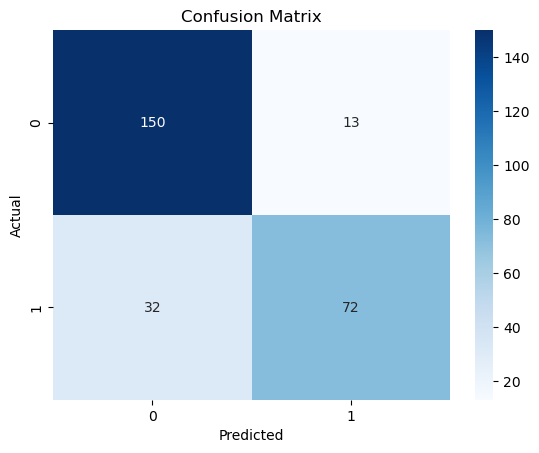

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, 
            annot=True,
            fmt = 'd',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [104]:
train2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,1.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,1.0,0.0,1.0


In [115]:
classes = pd.get_dummies(train['Pclass'], drop_first = True, dtype = float, prefix='Pclass')
classes.head()

,Pclass_2,Pclass_3
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,0.0
4,0.0,1.0


In [116]:
nonscale = pd.concat([train2,classes], axis = 1)

In [117]:
nonscale.drop(['Pclass'],axis = 1, inplace = True)
nonscale.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,0,22.0,1,0,7.2500,1.0,0.0,1.0,0.0,1.0
1,1,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,0.0
2,1,26.0,0,0,7.9250,0.0,0.0,1.0,0.0,1.0
3,1,35.0,1,0,53.1000,0.0,0.0,1.0,0.0,0.0
4,0,35.0,0,0,8.0500,1.0,0.0,1.0,0.0,1.0


In [118]:
nX = nonscale.drop(['Survived'], axis = 1)
ny = nonscale['Survived']

In [119]:
nX_train,nX_test,ny_train,ny_test = train_test_split(nX,ny, test_size=0.2)

In [122]:
nonscalelog = LogisticRegression(max_iter=1000)

In [123]:
nonscalelog.fit(nX_train,ny_train)

LogisticRegression(max_iter=1000)

In [124]:
predictions = nonscalelog.predict(nX_test)

<Axes: >

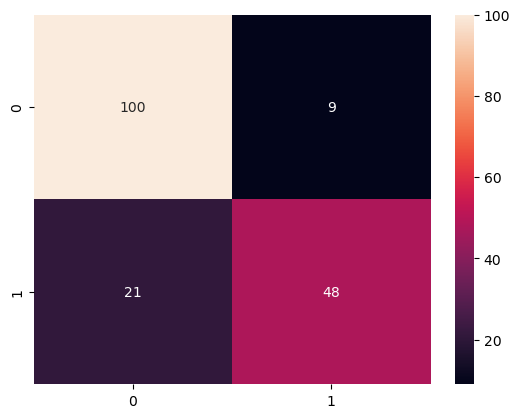

In [125]:
ncm = confusion_matrix(ny_test,predictions)
sns.heatmap(ncm, fmt='d', annot=True)

In [126]:
print (classification_report(ny_test,predictions))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       109
           1       0.84      0.70      0.76        69

    accuracy                           0.83       178
   macro avg       0.83      0.81      0.82       178
weighted avg       0.83      0.83      0.83       178



In [127]:
from sklearn.preprocessing import StandardScaler

In [128]:
scaler = StandardScaler()

In [129]:
scaler.fit(nX_train)

StandardScaler()

In [130]:
nX_train_scaled = scaler.transform(nX_train)
nX_test_scaled = scaler.transform(nX_test)

In [131]:
scallogmodel = LogisticRegression(max_iter= 1000)
scallogmodel.fit(nX_train_scaled, ny_train)

LogisticRegression(max_iter=1000)

In [132]:
npredictions = scallogmodel.predict(nX_test_scaled)

In [133]:
print (confusion_matrix(ny_test,npredictions))

[[100   9]
 [ 21  48]]
